<a href="https://colab.research.google.com/github/bihjane/Data-science-and-AI-K-12-teaching-tools/blob/main/Copy_of_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Digit Recognition - Training a Neural Network

## What is MNIST?

MNIST is a dataset of 70,000 handwritten digits (0-9):
- **60,000 training images** - Used to teach the network
- **10,000 test images** - Used to evaluate how well it learned
- Each image is **28×28 pixels** in grayscale (0-255)

This is considered the "Hello World" of deep learning!

## Step 1: Import Libraries

In [23]:
# Import necessary libraries
from keras.datasets import mnist
from keras import models
from keras import layers
import numpy as np
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the MNIST Dataset

Keras provides MNIST pre-loaded. The data is already split into training and test sets.

In [41]:
# Take preprocessing from titanic data set and use it to clean the data
# Load data - automatically downloads first time
import os
import gdown

url = 'https://drive.google.com/uc?id=124vrWZVJY0wOiFsXlTRpKDW2fHkzVub9'
output_path = 'career.csv'
gdown.download(url, output_path, quiet=False, fuzzy=True)




Downloading...
From: https://drive.google.com/uc?id=124vrWZVJY0wOiFsXlTRpKDW2fHkzVub9
To: /content/career.csv
100%|██████████| 398k/398k [00:00<00:00, 61.7MB/s]


'career.csv'

In [42]:
!dir

career.csv  sample_data


In [43]:
# read the data
df = pd.read_csv('career.csv')
df.head()




,Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_Ranking,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
0,S00001,24,Male,3.58,1052,291,3.96,Arts,3,7,2,9,8,5,27200.0,4,5,Entry,7,No
1,S00002,21,Other,2.52,1211,112,3.63,Law,4,7,3,8,1,4,25000.0,1,1,Mid,7,No
2,S00003,28,Female,3.42,1193,715,2.63,Medicine,4,8,1,1,9,0,42400.0,9,3,Entry,7,No
3,S00004,25,Male,2.43,1497,170,2.81,Computer Science,3,9,1,10,6,1,57400.0,7,5,Mid,5,No
4,S00005,22,Male,2.08,1012,599,2.48,Engineering,4,6,4,10,9,4,47600.0,9,5,Entry,2,No


## Step 3: Visualize Sample Images

Let's look at some of the handwritten digits in the dataset.

Image Index: 7777
Label: 8


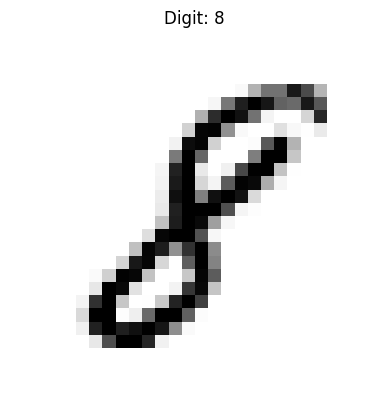

In [44]:
# Display a single image
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

image_index = 7777  # Try different values between 0-59999
print(f"Image Index: {image_index}")
print(f"Label: {train_labels[image_index]}")
plt.imshow(train_images[image_index], cmap='Greys')
plt.title(f"Digit: {train_labels[image_index]}")
plt.axis('off')
plt.show()

In [ ]:
# Display multiple images in a grid
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images[i], cmap='Greys')
    ax.set_title(f"Label: {train_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## Step 4: Examine Data Structure

Understanding the shape and structure of our data is crucial.

In [ ]:
# Check data details
print("Training set:")
print(f"  Images shape: {train_images.shape}")  # (60000, 28, 28)
print(f"  Labels shape: {train_labels.shape}")  # (60000,)
print(f"  First 10 labels: {train_labels[:10]}")
print(f"  Pixel value range: {train_images.min()} to {train_images.max()}")
print()
print("Test set:")
print(f"  Images shape: {test_images.shape}")   # (10000, 28, 28)
print(f"  Labels shape: {test_labels.shape}")   # (10000,)

## Step 5: Preprocess the Data

### 5a. Reshape the Data

We need to flatten each 28×28 image into a 1D array of 784 values.

In [ ]:
# Reshape from (samples, 28, 28) to (samples, 784)
train_images = train_images.reshape((60000, 28 * 28))
test_images = test_images.reshape((10000, 28 * 28))

print(f"Training images reshaped: {train_images.shape}")
print(f"Test images reshaped: {test_images.shape}")

### 5b. Normalize Pixel Values

Convert pixel values from 0-255 to 0-1 range for better neural network performance.

In [ ]:
# Normalize: divide by 255 to get values between 0 and 1
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

print(f"After normalization - Min: {train_images.min()}, Max: {train_images.max()}")

### 5c. Convert Labels to Categorical (One-Hot Encoding)

Convert integer labels (0-9) to binary vectors.

Example: Label 3 becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

In [ ]:
# Show labels before conversion
print("Before one-hot encoding:")
print(f"First 10 labels: {train_labels[:10]}")
print()

# Convert to categorical
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

print("After one-hot encoding:")
print(f"Labels shape: {train_labels.shape}")
print(f"First label: {train_labels[0]}")
print(f"This represents digit: {np.argmax(train_labels[0])}")

## Step 6: Build the Neural Network

We'll create a simple neural network with:
- Input layer: 784 neurons (one per pixel)
- Hidden layer: 512 neurons with ReLU activation
- Output layer: 10 neurons (one per digit) with softmax activation

In [ ]:
# Create the network architecture
network = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(28 * 28,)),
    layers.Dense(10, activation='softmax')
])

# Display the network architecture
network.summary()

## Step 7: Compile the Network

Configure the learning process:
- **Optimizer**: rmsprop (adjusts weights during training)
- **Loss function**: categorical_crossentropy (measures prediction error)
- **Metrics**: accuracy (tracks performance)

In [ ]:
network.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Step 8: Train the Network

Train for 5 epochs (5 complete passes through the training data).

In [ ]:
# Train the network
history = network.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128,
    validation_split=0.2  # Use 20% of training data for validation
)

## Step 9: Evaluate the Model

Test the trained network on unseen test data.

In [ ]:
# Evaluate on test set
test_loss, test_accuracy = network.evaluate(test_images, test_labels)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

## Step 10: Visualize Training Progress

In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Over Time')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss Over Time')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Step 11: Save the Model

Save the trained model for later use in the exploration notebook.

In [ ]:
# Save the trained model
model.save('mnist_model.h5')
print("Model saved as 'mnist_model.h5'")

## Summary

We successfully:
1. Loaded the MNIST dataset
2. Preprocessed the data (reshape, normalize, one-hot encode)
3. Built a neural network with 784 inputs → 512 hidden neurons → 10 outputs
4. Trained the network for 5 epochs
5. Achieved high accuracy on the test set
6. Saved the model for future use

**Next:** Use the saved model in the MNIST_Explored notebook to analyze predictions!